# EDA — Corpus de licitações ComprasNet DF 2025

Análise exploratória do corpus `data/processed/licitacoes_corpus.jsonl` (423 editais).
Objetivos: entender a distribuição das **macroáreas** (label da classificação), de
modalidade/tipo, o **tamanho dos textos**, o **valor homologado** por área e checar o
**vazamento de label** discutido no guia (§6.1).

### Célula 1 — Configuração do Ambiente e Carregamento do Corpus

In [38]:
import json  # biblioteca para ler e escrever dados no formato JSON

import sys  # acesso ao ambiente Python (usado para ajustar o path de importação)
from collections import Counter  # contador de frequências (usado nas células seguintes)
from pathlib import Path  # caminhos de arquivo de forma portável entre sistemas

import matplotlib.pyplot as plt  # biblioteca de gráficos (usada nas células seguintes)

from IPython.display import HTML, display  # exibe tabelas HTML alinhadas no notebook


def br_num(n: int | float) -> str:
    """Formata número inteiro no padrão brasileiro (1.234)."""
    return f"{int(n):,}".replace(",", ".")


def br_money(v: float) -> str:
    """Formata valor monetário no padrão brasileiro (R$ 1.234.567)."""
    return "R$ " + f"{v:,.0f}".replace(",", ".")


def show_table(
    titulo: str,
    colunas: list[str],
    linhas: list[list[str]],
    alinhamentos: list[str] | None = None,
) -> None:
    """Renderiza tabela HTML com colunas alinhadas."""
    if alinhamentos is None:
        alinhamentos = ["left"] + ["right"] * (len(colunas) - 1)
    estilo_th = (
        "padding:8px 12px;border:1px solid #475569;"
        "background:#1e40af;color:#ffffff;font-weight:600;"
    )
    estilo_td = (
        "padding:8px 12px;border:1px solid #cbd5e1;"
        "background:#ffffff;color:#111827;"
    )
    corpo = ""
    for linha in linhas:
        celulas = ""
        for valor, alin in zip(linha, alinhamentos):
            celulas += f"<td style='{estilo_td}text-align:{alin};'>{valor}</td>"
        corpo += f"<tr>{celulas}</tr>"
    cabecalho = "".join(
        f"<th style='{estilo_th}text-align:{a};'>{c}</th>"
        for c, a in zip(colunas, alinhamentos)
    )
    html = f"""
    <div style="margin:14px 0;font-family:Segoe UI,sans-serif;color:#e5e7eb;">
      <div style="font-size:14px;font-weight:bold;margin-bottom:8px;color:#f3f4f6;">{titulo}</div>
      <table style="border-collapse:collapse;font-size:13px;">
        <thead><tr>{cabecalho}</tr></thead>
        <tbody>{corpo}</tbody>
      </table>
    </div>
    """
    display(HTML(html))


# Descobre a raiz do projeto para conseguir importar módulos de src/
ROOT = Path.cwd()  # pasta atual de trabalho (geralmente notebooks/ ou a raiz do repo)
if (ROOT / "src").exists():  # se src/ está aqui, já estamos na raiz do projeto
    pass  # ROOT já está correto, não precisa alterar
elif (ROOT.parent / "src").exists():  # se src/ está um nível acima (caso cwd = notebooks/)
    ROOT = ROOT.parent  # sobe para a pasta pai, que é a raiz do repositório
sys.path.insert(0, str(ROOT))  # insere a raiz no início do path para "from src..." funcionar

from src.preprocess.labels import AREAS, area_for_orgao, normalize  # constantes e funções de label

CORPUS = ROOT / "data" / "processed" / "licitacoes_corpus.jsonl"  # arquivo: um edital JSON por linha
FIGURES = ROOT / "reports" / "figures"  # pasta onde os gráficos da EDA serão salvos
FIGURES.mkdir(parents=True, exist_ok=True)  # cria reports/figures/ se ainda não existir

records = []  # lista vazia que vai acumular todos os editais carregados
with CORPUS.open(encoding="utf-8") as f:  # abre o corpus em modo leitura com codificação UTF-8
    for line in f:  # itera linha a linha (cada linha = um edital em JSON)
        line = line.strip()  # remove espaços e quebras de linha no início e no fim
        if not line:  # pula linhas em branco (ex.: linha extra no fim do arquivo)
            continue  # volta ao início do loop e lê a próxima linha
        r = json.loads(line)  # transforma a string JSON da linha em um dicionário Python
        r["area"] = area_for_orgao(r.get("orgao_csv", ""))  # deriva a macroárea a partir do órgão
        records.append(r)  # adiciona o edital enriquecido à lista records

campos = list(records[0].keys()) if records else []  # nomes das colunas do primeiro edital
descricoes = {
    "id": "identificador interno",
    "numero_licitacao": "número da licitação no ComprasNet",
    "modalidade": "tipo de procedimento (pregão, dispensa...)",
    "situacao": "status do edital",
    "orgao_csv": "órgão comprador (usado para derivar o label)",
    "orgao_html": "órgão em HTML",
    "tipo": "material ou serviço",
    "objeto_csv": "descrição do objeto (texto plano)",
    "objeto_html": "descrição do objeto (HTML)",
    "total_homologado": "valor total homologado (R$)",
    "edital_url": "link do edital",
    "texto": "texto completo concatenado",
    "num_caracteres": "tamanho em caracteres",
    "num_itens": "quantidade de itens",
    "area": "macroárea de gasto (label da classificação)",
}

show_table(
    "TABELA 1 — Visão geral do corpus carregado",
    ["Métrica", "Valor"],
    [
        ["Arquivo de origem", CORPUS.name],
        ["Total de editais", br_num(len(records))],
        ["Campos por edital", br_num(len(campos))],
        ["Label (macroárea)", "area (derivado de orgao_csv)"],
    ],
    ["left", "left"],
)

show_table(
    "TABELA 1b — Colunas disponíveis em cada registro",
    ["#", "Campo", "Descrição"],
    [[str(i), c, descricoes.get(c, "")] for i, c in enumerate(campos, 1)],
    ["right", "left", "left"],
)

Métrica,Valor
Arquivo de origem,licitacoes_corpus.jsonl
Total de editais,114
Campos por edital,15
Label (macroárea),area (derivado de orgao_csv)


#,Campo,Descrição
1,id,identificador interno
2,numero_licitacao,número da licitação no ComprasNet
3,modalidade,"tipo de procedimento (pregão, dispensa...)"
4,situacao,status do edital
5,orgao_csv,órgão comprador (usado para derivar o label)
6,orgao_html,órgão em HTML
7,tipo,material ou serviço
8,objeto_csv,descrição do objeto (texto plano)
9,objeto_html,descrição do objeto (HTML)
10,total_homologado,valor total homologado (R$)


#### Resultado da Célula 1 — O que foi carregado?

A **Tabela 1** resume o corpus pronto para análise:

| O que observar | Como interpretar |
|----------------|------------------|
| **Total de editais** | Tamanho da amostra; quanto menor, mais instáveis ficam métricas por classe. |
| **Campo `area`** | Label da classificação, derivado do órgão — não é anotado manualmente no texto. |
| **`objeto_html` vs `texto`** | O objeto é a descrição da compra; o texto completo inclui órgão, itens e metadados. |
| **`total_homologado`** | Valor em R$ após a licitação; usado na análise de gasto por área. |

**Conclusão:** o corpus está estruturado e cada edital ganhou o campo `area` para as análises seguintes.

## 1. Distribuição das areas macros (label)

O label é derivado do órgão (`orgao_csv`) por palavras-chave — ver `src/preprocess/labels.py`.

### Célula 2 — Gráfico de Distribuição das Macroáreas

Macroárea,N editais,% do total
Saude,73,64.0%
Saneamento,27,23.7%
Seguranca,4,3.5%
Educacao,0,0.0%
Infraestrutura/Obras,0,0.0%
Administracao/Outros,10,8.8%


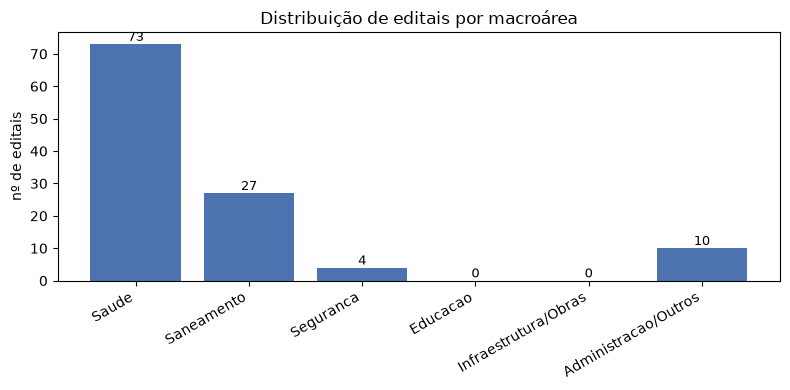

In [39]:
area_counts = Counter(r["area"] for r in records)  # conta quantos editais existem em cada macroárea
ordered = [(a, area_counts.get(a, 0)) for a in AREAS]  # lista (área, contagem) na ordem fixa de AREAS
total = len(records)  # total de editais para calcular percentuais

show_table(
    "TABELA 2 — Distribuição de editais por macroárea (label)",
    ["Macroárea", "N editais", "% do total"],
    [
        [a, br_num(n), f"{100 * n / total:.1f}%" if total else "0,0%"]
        for a, n in ordered
    ],
)

fig, ax = plt.subplots(figsize=(8, 4))  # cria figura 8x4 polegadas com um eixo
ax.bar([a for a, _ in ordered], [n for _, n in ordered], color="#4C72B0")  # gráfico de barras por área
ax.set_ylabel("nº de editais")  # rótulo do eixo vertical
ax.set_title("Distribuição de editais por macroárea")  # título do gráfico
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")  # inclina rótulos do eixo X para legibilidade
for i, (_, n) in enumerate(ordered):  # enumera barras para anotar valores
    ax.text(i, n + 1, str(n), ha="center", fontsize=9)  # escreve o número acima de cada barra
fig.tight_layout()  # ajusta margens para não cortar rótulos
fig.savefig(FIGURES / "eda_areas.png", dpi=120)  # salva figura em reports/figures/
plt.show()  # exibe o gráfico no notebook

#### Resultado da Célula 2 — Distribuição das macroáreas

A **Tabela 2** e o gráfico de barras mostram **quantos editais** existem em cada macroárea (label).

| Padrão típico | Implicação para o modelo |
|---------------|--------------------------|
| Uma ou duas áreas com muitos editais | Classe majoritária; o modelo pode prever sempre a mesma área e ainda ter acurácia alta. |
| Áreas com 0 ou poucos editais | F1 e recall instáveis; difícil aprender padrões. |
| Barras muito desiguais | Usar `class_weight` no treino e reportar **F1 por classe**, não só acurácia. |

**Conclusão:** o corpus é **fortemente desbalanceado**. Saúde costuma dominar; Educação e Infraestrutura frequentemente aparecem com poucos ou zero exemplos nesta amostra.

## 2. Modalidade e tipo de contratação

### Célula 3 — Contagem de Modalidade e Tipo de Contratação

In [40]:
rotulos = {"modalidade": "Modalidade de licitação", "tipo": "Tipo de contratação"}  # títulos das tabelas
tabela_num = 3  # contador de tabelas impressas

for campo in ("modalidade", "tipo"):  # analisa dois campos categóricos do corpus
    contagem = Counter(r.get(campo, "") or "(vazio)" for r in records).most_common()  # frequências
    total_campo = sum(n for _, n in contagem)  # soma para percentual
    show_table(
        f"TABELA {tabela_num} — {rotulos[campo]}",
        ["Valor", "N", "%"],
        [
            [valor, br_num(n), f"{100 * n / total_campo:.1f}%"]
            for valor, n in contagem
        ],
        ["left", "right", "right"],
    )
    tabela_num += 1  # próxima tabela na sequência

Valor,N,%
PREGÃO,103,90.4%
DISPENSA DE LICITAÇÃO,11,9.6%


Valor,N,%
MATERIAL,103,90.4%
SERVIÇO,11,9.6%


## 3. Tamanho dos textos (em palavras)

#### Resultado da Célula 3 — Modalidade e tipo de contratação

As **Tabelas 3 e 4** mostram como os editais se distribuem em variáveis administrativas (não são o label da classificação).

| Campo | O que significa | Uso na EDA |
|-------|-----------------|------------|
| **Modalidade** | Regra legal do procedimento (ex.: pregão, dispensa). | Verifica se o corpus é homogêneo ou misto. |
| **Tipo** | Natureza da compra: material ou serviço. | Contexto para entender o vocabulário dos textos. |

**Conclusão:** se quase todos forem **pregão + material**, o corpus é homogêneo em formato — a classificação por macroárea depende do *conteúdo*, não da modalidade.

### Célula 4 — Histograma do Tamanho dos Textos em Palavras

Métrica,Valor
Mínimo,13 palavras
Mediana,501 palavras
Máximo,4.021 palavras
Editais com > 512 palavras,55
% acima de 512 palavras,48.2%


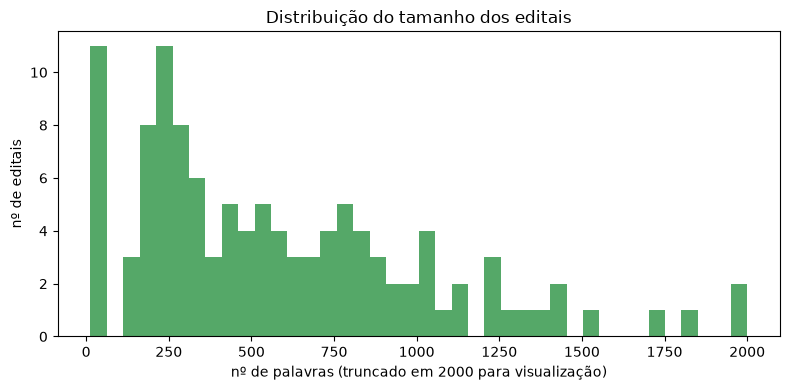

In [41]:
word_counts = [len((r.get("texto") or "").split()) for r in records]  # nº de palavras em cada edital
word_counts_sorted = sorted(word_counts)  # ordena tamanhos para calcular estatísticas
n = len(word_counts_sorted)  # total de editais com texto contado
mediana = word_counts_sorted[n // 2] if n else 0  # valor central da distribuição de tamanhos
acima_512 = sum(1 for w in word_counts if w > 512)  # editais que excedem limite típico do BERT

show_table(
    "TABELA 5 — Estatísticas do tamanho dos textos (em palavras)",
    ["Métrica", "Valor"],
    [
        ["Mínimo", br_num(min(word_counts) if word_counts else 0) + " palavras"],
        ["Mediana", br_num(mediana) + " palavras"],
        ["Máximo", br_num(max(word_counts) if word_counts else 0) + " palavras"],
        ["Editais com > 512 palavras", br_num(acima_512)],
        ["% acima de 512 palavras", f"{100 * acima_512 / n:.1f}%" if n else "0,0%"],
    ],
    ["left", "right"],
)

fig, ax = plt.subplots(figsize=(8, 4))  # nova figura para o histograma
ax.hist([min(w, 2000) for w in word_counts], bins=40, color="#55A868")  # histograma (cap em 2000 palavras)
ax.set_xlabel("nº de palavras (truncado em 2000 para visualização)")  # eixo X
ax.set_ylabel("nº de editais")  # eixo Y
ax.set_title("Distribuição do tamanho dos editais")  # título
fig.tight_layout()  # ajusta layout
fig.savefig(FIGURES / "eda_tamanho_texto.png", dpi=120)  # salva PNG
plt.show()  # mostra histograma

## 4. Valor homologado por área

#### Resultado da Célula 4 — Tamanho dos textos

A **Tabela 5** e o histograma descrevem o **comprimento em palavras** do campo `texto`.

| Métrica | Por que importa |
|---------|-----------------|
| **Mediana** | Tamanho “típico” de um edital; menos sensível a outliers que a média. |
| **Máximo** | Editais muito longos podem conter listas de itens extensas. |
| **% acima de 512** | BERT/BERTimbau truncam em ~512 **tokens**; texto além disso é cortado. |

**Conclusão:** se a maioria passar de 512 palavras, o classificador verá só o **início** do edital. Vale considerar `objeto_html` (mais curto) ou truncamento consciente na discussão.

### Célula 5 — Tabela e Gráfico de Valor Homologado por Macroárea

Macroárea,N c/ valor,Soma,Mediana
Saude,73,R$ 186.703.084,R$ 606.627
Saneamento,27,R$ 40.367.974,R$ 326.316
Seguranca,4,R$ 1.715.638,R$ 592.924
Educacao,0,—,—
Infraestrutura/Obras,0,—,—
Administracao/Outros,10,R$ 10.124.394,R$ 5.500


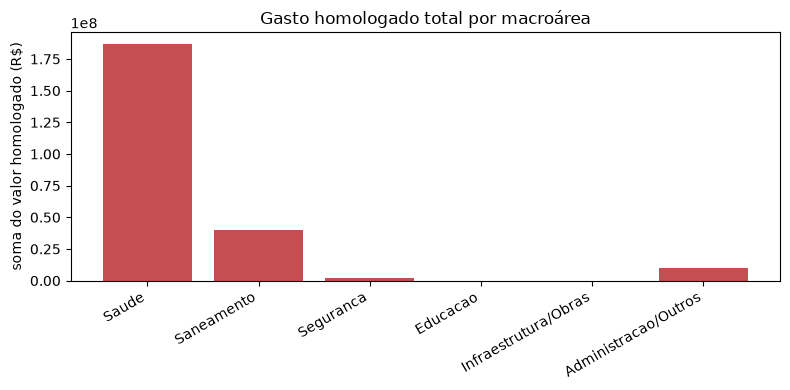

In [42]:
def parse_valor(v: str) -> float | None:  # converte string de valor BR em float ou None
    """Converte 'R$ 1.234,56' (formato BR) para float; None se não numérico."""
    if not v:  # valor vazio ou ausente
        return None  # sinaliza que não há número válido
    s = str(v).replace("R$", "").strip().replace(".", "").replace(",", ".")  # normaliza formato brasileiro
    try:  # tenta conversão numérica
        return float(s)  # retorna valor em reais como float
    except ValueError:  # string não representa um número
        return None  # retorna None em caso de erro


por_area = {a: [] for a in AREAS}  # dicionário: cada macroárea -> lista de valores homologados
for r in records:  # percorre todos os editais
    val = parse_valor(r.get("total_homologado"))  # lê e converte o valor homologado
    if val is not None and val > 0:  # ignora valores ausentes ou zero
        por_area[r["area"]].append(val)  # acumula valor na área correspondente

linhas_valor = []
for a in AREAS:  # uma linha por macroárea
    vals = sorted(por_area[a])  # valores da área em ordem crescente
    if vals:  # se há pelo menos um valor numérico
        linhas_valor.append([
            a,
            br_num(len(vals)),
            br_money(sum(vals)),
            br_money(vals[len(vals) // 2]),
        ])
    else:  # área sem valores válidos
        linhas_valor.append([a, "0", "—", "—"])

show_table(
    "TABELA 6 — Valor homologado por macroárea",
    ["Macroárea", "N c/ valor", "Soma", "Mediana"],
    linhas_valor,
    ["left", "right", "right", "right"],
)

somas = [sum(por_area[a]) for a in AREAS]  # soma de gastos por macroárea (para o gráfico)
fig, ax = plt.subplots(figsize=(8, 4))  # figura do gráfico de gastos
ax.bar(AREAS, somas, color="#C44E52")  # barras com gasto total por área
ax.set_ylabel("soma do valor homologado (R$)")  # eixo Y em reais
ax.set_title("Gasto homologado total por macroárea")  # título
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")  # inclina nomes das áreas
fig.tight_layout()  # ajusta margens
fig.savefig(FIGURES / "eda_valor_por_area.png", dpi=120)  # salva figura
plt.show()  # exibe gráfico

## 5. Vazamento de label: o órgão aparece no texto?

O label vem do órgão. Se o **nome do órgão** estiver dentro do `texto`, o classificador
pode "colar" em vez de aprender o conteúdo. Medimos quantos editais contêm uma das
palavras-chave da sua própria área no `texto` vs no `objeto_html`.

#### Resultado da Célula 5 — Valor homologado por área

A **Tabela 6** e o gráfico comparam o **gasto público homologado** entre macroáreas.

| Coluna | Significado |
|--------|-------------|
| **N c/ valor** | Quantos editais da área têm valor numérico válido. |
| **Soma (R$)** | Gasto total homologado na área (soma de todos os editais). |
| **Mediana (R$)** | Valor “típico” de um edital na área (menos afetada por outliers). |

**Conclusão:** áreas com poucos editais podem ter **soma alta** se houver contratos grandes (ex.: obras). Saúde e Saneamento costumam concentrar volume financeiro — insight útil para a apresentação do projeto.

### Célula 6 — Análise de Vazamento de Label por Palavras-Chave

In [43]:
from src.preprocess.labels import AREA_KEYWORDS  # mapa área -> palavras-chave do órgão

kw_by_area = dict(AREA_KEYWORDS)  # cópia do dicionário de palavras-chave por área


def contem_keyword(texto: str, area: str) -> bool:  # verifica se alguma keyword da área aparece no texto
    kws = kw_by_area.get(area)  # busca palavras-chave da macroárea
    if not kws:  # Administração/Outros não tem keyword própria
        return False  # nessa área não há o que procurar
    alvo = normalize(texto)  # normaliza texto (minúsculas, sem acento) para comparação
    return any(kw in alvo for kw in kws)  # True se qualquer keyword estiver contida no texto


com_kw = [r for r in records if r["area"] in kw_by_area]  # editais de áreas com palavra-chave definida
vaz_texto = sum(contem_keyword(r.get("texto", ""), r["area"]) for r in com_kw)  # vazamento no campo texto
vaz_obj = sum(contem_keyword(r.get("objeto_html", ""), r["area"]) for r in com_kw)  # vazamento no objeto_html
base = len(com_kw)  # denominador para calcular percentuais

if base:
    show_table(
        "TABELA 7 — Vazamento de label (palavra-chave da área no texto)",
        ["Campo analisado", "Com vazamento", "Total", "Taxa"],
        [
            ["texto (completo)", br_num(vaz_texto), br_num(base), f"{100 * vaz_texto / base:.1f}%"],
            ["objeto_html (só objeto)", br_num(vaz_obj), br_num(base), f"{100 * vaz_obj / base:.1f}%"],
        ],
        ["left", "right", "right", "right"],
    )

print(f"Editais analisados (áreas com palavra-chave): {base}")
print("Nota: quanto maior a taxa em 'texto', mais fácil o modelo colar no label pelo órgão.")

Campo analisado,Com vazamento,Total,Taxa
texto (completo),104,104,100.0%
objeto_html (só objeto),67,104,64.4%


Editais analisados (áreas com palavra-chave): 104
Nota: quanto maior a taxa em 'texto', mais fácil o modelo colar no label pelo órgão.


## Conclusões da EDA

- **Desbalanceamento forte** entre areas macros → usar `class_weight`, reportar F1 por classe.
- Boa parte dos editais passa de **512 palavras** → BERTimbau truncará; considerar isso.
- O **gasto** concentra-se em poucas áreas (Saúde/Saneamento) — insight para a apresentação.
- **Vazamento confirmado**: o órgão aparece no `texto` com frequência muito maior que no
  `objeto_html`, justificando a escolha de entrada da classificação.

#### Resultado da Célula 6 — Vazamento de label

A **Tabela 7** mede se a **palavra-chave da macroárea** (ex.: “SAUDE”) aparece no próprio texto do edital.

| Campo | Interpretação |
|-------|---------------|
| **`texto`** | Inclui órgão, cabeçalhos e metadados → taxa de vazamento costuma ser **alta**. |
| **`objeto_html`** | Só a descrição do objeto → taxa costuma ser **menor** e mais honesta. |

**Conclusão:** se `texto` tiver taxa muito maior que `objeto_html`, o classificador pode aprender a “adivinhar” a área pelo **nome do órgão** em vez do conteúdo. Por isso usamos **`objeto_html`** como entrada da classificação (guia §6.1).